# Exploring Convolutional Layers Through Data and Experiments

---

**Author:** Daniel Patiño Mejia


### Context and Motivation

Neural networks are not treated as black boxes but as architectural components whose design choices affect performance, scalability, and interpretability.
This notebook focuses on convolutional layers as a concrete example of how inductive bias is introduced into learning systems.

Rather than following a recipe, this notebook will show and explain the selection, analysis, and experiment with a convolutional architecture using a real dataset.

### Notebook Setup

Before compile, make sure you have a Python version 3.12.* or lower; this guarantees that all the libraries are installed correctly and prevent issued during compilation

In [99]:
%pip install numpy matplotlib pandas tensorflow tensorflow_datasets importlib_resources

Note: you may need to restart the kernel to use updated packages.


In [100]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
    from tensorflow.keras.losses import BinaryCrossentropy
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception as exc:
    TF_AVAILABLE = False
    print("TensorFlow is not available in this environment.")
    print("You can still run the NumPy sections.")
    print("Reason:", repr(exc))

# Make NumPy output easier to read.
np.set_printoptions(precision=4, suppress=True)

# Libraries and language versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

TensorFlow version: 2.21.0
Python version: 3.12.13 (main, Aug  7 2026, 02:25:39) [Clang 22.1.3 ]
NumPy version: 2.5.2
Matplotlib version: 3.11.1


### Dataset setup

In [101]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Construct a tf.data.Dataset
# Mejor aletoriedad, recomendado para entrenamiento
ds_train, train_info = tfds.load('horses_or_humans', split='train', shuffle_files=True, with_info=True)
# Orden fijo, util para test
ds_test, test_info = tfds.load('horses_or_humans', split='test', shuffle_files=False, with_info=True)

# Build your input pipeline
ds_train = ds_train.shuffle(1027).batch(32).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.batch(32).prefetch(tf.data.AUTOTUNE)

**Dataset justification:** I picked `horses_or_humans` from TensorFlow Datasets: an image dataset with two classes (horses and humans) where the goal is to classify each image as one or the other. It's a good fit for convolutional layers because the classes are defined by shape and silhouette — patterns that show up in local regions of the image and repeat across different positions, which is exactly what convolution is built to detect through its filters and feature maps.

At 153.53 MiB total, it comfortably fits in memory on a laptop or a free-tier cloud notebook — no special handling needed.

### 1. Dataset Exploration (EDA)

In this section we will be exploring the selected dataset providing a concise analysis to understand its structure before training

#### 1.1. Dataset size and class distribution

The dataset has 1,283 images total, split 80/20 into train and test. Each record has two fields — image and label — where label is 0 for horse and 1 for human. Let's check the class balance in each split.

In [102]:
from collections import Counter

class_names = train_info.features["label"].names
print("Class names:", class_names, "\n")

all_train_labels = []
all_test_labels = []

for example in ds_train:
    batch_labels = example["label"].numpy()
    all_train_labels.extend(batch_labels.tolist())

train_count = Counter(all_train_labels)

print("Train class Distribution: \n")
for train_class_id, train_quantity in train_count.items():
    print(f"{class_names[train_class_id]}: {train_quantity} \n")

for example in ds_test:
    batch_labels = example["label"].numpy()
    all_test_labels.extend(batch_labels.tolist())

test_count = Counter(all_test_labels)

print("Test Class Distribution \n")
for test_class_id, test_quantity in test_count.items():
    print(f"{class_names[test_class_id]}: {test_quantity} \n")

Class names: ['horses', 'humans'] 

Train class Distribution: 

humans: 527 

horses: 500 

Test Class Distribution 

horses: 128 

humans: 128 



#### 1.2. Image dimensions and channels

Next, we will see the dimension and channels of each image in the dataset, with this information we can define the image type (1 for gray scale, 2 for RGB and 3 for RGBA) and the weight of it.

In [103]:
for example in ds_train.take(1):
  image= example["image"]
  print(image.shape)

(32, 300, 300, 3)


The 32 means the batch size that we defined previously, both 300 means the resolution of the image and the 3 means that the images are RGB

#### 1.3. Examples of samples per class


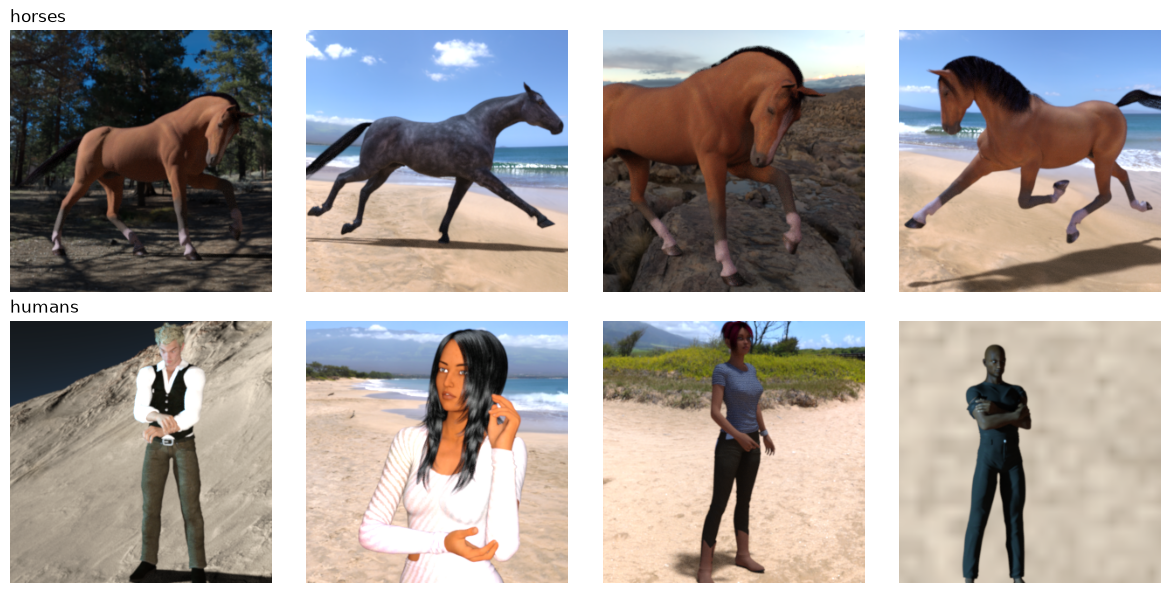

In [104]:
samples_per_class = 4
class_images = {name: [] for name in class_names}

for batch in ds_train.take(5):
    images = batch["image"].numpy()
    labels = batch["label"].numpy()
    for img, label in zip(images, labels):
        name = class_names[label]
        if len(class_images[name]) < samples_per_class:
            class_images[name].append(img)
    if all(len(v) >= samples_per_class for v in class_images.values()):
        break

fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(12, 6))
for row, name in enumerate(class_names):
    for col, img in enumerate(class_images[name]):
        axes[row, col].imshow(img.astype("uint8"))
        axes[row, col].axis("off")
    axes[row, 0].set_title(name, loc="left")
plt.tight_layout()
plt.show()

#### 1.4. Any preprocessing needed (normalization, resizing)

Resizing isn't needed — every image is already a fixed 300x300x3, as confirmed in 1.2, so batches are naturally uniform.

Normalization is needed, though. As seen in the samples above, pixel values are stored as `uint8` in `[0, 255]`. Feeding raw values in that range into a network tends to produce large, unstable gradients during training, so we rescale to `[0, 1]` by dividing by 255 — that's what happens below.

In [105]:
def normalize_img(example):
    image = tf.cast(example["image"], tf.float32) / 255.0
    return {"image": image, "label": example["label"]}

ds_train = ds_train.map(normalize_img)
ds_test = ds_test.map(normalize_img)

for batch in ds_train.take(1):
    print("Min pixel value:", tf.reduce_min(batch["image"]).numpy())
    print("Max pixel value:", tf.reduce_max(batch["image"]).numpy())

Min pixel value: 0.0
Max pixel value: 1.0


### 2. Baseline Model (Non-Convolutional)

In this section, we will be implementing a baseline neural network without convolutional layers (This will be touched in the next section).

#### 2.1. Architecture

For training I switched to Keras instead of continuing the manual NumPy version. Keras handles backpropagation and optimization through automatic differentiation and built-in optimizers — same math (dot products, activations, gradients), just without me deriving and coding the backward pass by hand. It's also the practical choice given the SageMaker deployment step later, since SageMaker has native support for Keras/TensorFlow models.

Three layers: input (the flattened 300x300x3 image, 270,000 features), a hidden layer of 64 units with ReLU, and an output unit with sigmoid. ReLU is the standard pick for hidden layers — cheap, and it avoids the vanishing-gradient problem sigmoid/tanh have in deeper nets. Sigmoid on the output squashes the result into [0, 1], read as the probability the image is class 1 (human).

In [106]:
keras_baseline_model = Sequential([
    Flatten(input_shape=(300, 300, 3)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid"),
])

keras_baseline_model.summary()

/home/daniel/Documents/University/Eighth_Semester/TDSE/.venv-1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 270000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │    17,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,280,129 (65.92 MB)

 Trainable params: 17,280,129 (65.92 MB)

 Non-trainable params: 0 (0.00 B)

That's 17,280,129 parameters for about 1,027 training images — a massive mismatch. My first instinct was to fix this by shrinking the hidden layer, but that doesn't really solve it: even at 16 units, the first layer would still have millions of parameters, because almost all of them come from flattening the 270,000-pixel image, not from the hidden layer size. The real problem is architectural, not a hyperparameter to tune — and that's actually the point of this baseline. It has no way to exploit the image's spatial structure, so it's the reference point I'll compare the CNN against later.

#### 2.2. Training and performance validation

To monitor overfitting during training without touching the test set, we carve out 15% of the `train` split as a validation set. This is done directly on the raw TFDS split (before shuffle/batch) so the split boundary stays stable across epochs — reusing `ds_train` with `.take()/.skip()` would leak data between train and validation every epoch, since `shuffle()` reshuffles by default on each iteration.

In [107]:
ds_train_raw, _ = tfds.load('horses_or_humans', split='train[:85%]', shuffle_files=True, with_info=True)
ds_val_raw, _ = tfds.load('horses_or_humans', split='train[85%:]', shuffle_files=False, with_info=True)

ds_train = ds_train_raw.map(normalize_img).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val_raw.map(normalize_img).batch(32).prefetch(tf.data.AUTOTUNE)

print("Train batches:", tf.data.experimental.cardinality(ds_train).numpy())
print("Validation batches:", tf.data.experimental.cardinality(ds_val).numpy())

Train batches: 28
Validation batches: 5


In [108]:
def to_supervised(example):
    return example["image"], example["label"]

ds_train_sup = ds_train.map(to_supervised)
ds_val_sup = ds_val.map(to_supervised)

keras_baseline_model.compile(
    loss=BinaryCrossentropy(),
    metrics=["accuracy"],
)

history = keras_baseline_model.fit(
    ds_train_sup,
    validation_data=ds_val_sup,
    epochs=30,
)

Epoch 1/30


/home/daniel/Documents/University/Eighth_Semester/TDSE/.venv-1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.5223 - loss: 139.9287 - val_accuracy: 0.4416 - val_loss: 71.8703
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.5441 - loss: 74.6748 - val_accuracy: 0.6104 - val_loss: 49.1778
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.5659 - loss: 60.6771 - val_accuracy: 0.4935 - val_loss: 77.8850
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.6701 - loss: 48.0730 - val_accuracy: 0.4610 - val_loss: 117.3360
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.6861 - loss: 35.7446 - val_accuracy: 0.5649 - val_loss: 100.2793
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.6770 - loss: 46.8012 - val_accuracy: 0.5260 - val_loss: 69.5280
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.7560 - loss: 33.4305 - val_accuracy: 0.8247 - val_loss: 9.4234
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.7377 - loss: 34.1556 - val_accura

#### 2.3. Observed validations

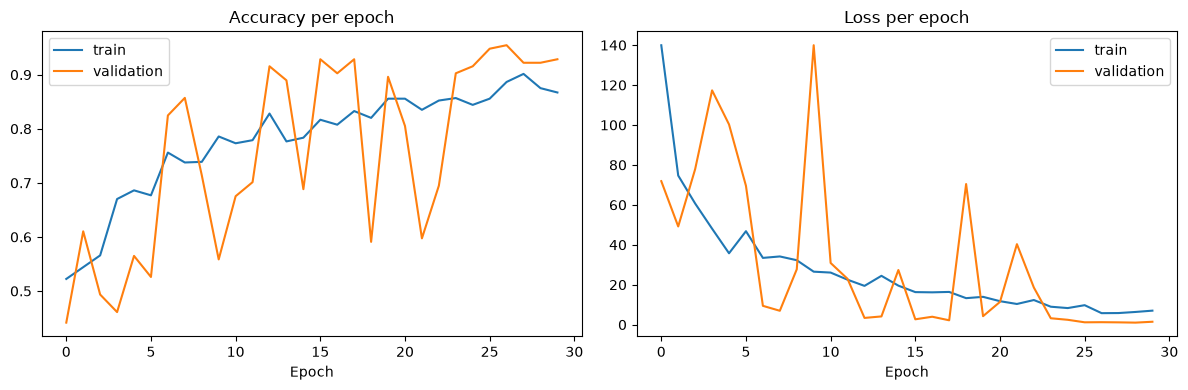

Final train accuracy: 0.8671248555183411
Final val accuracy: 0.9285714030265808
Best val accuracy: 0.9545454382896423 at epoch 27


In [109]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="train")
axes[0].plot(history_df["val_accuracy"], label="validation")
axes[0].set_title("Accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["loss"], label="train")
axes[1].plot(history_df["val_loss"], label="validation")
axes[1].set_title("Loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = history_df["val_accuracy"].idxmax()
print("Final train accuracy:", history_df["accuracy"].iloc[-1])
print("Final val accuracy:", history_df["val_accuracy"].iloc[-1])
print("Best val accuracy:", history_df["val_accuracy"].iloc[best_epoch], "at epoch", best_epoch + 1)

Training ran for 30 epochs. Final train accuracy was 86.7%, but train loss stayed huge the whole way, starting at 139.9 and mostly sitting between 7 and 30, way higher than you'd expect from binary cross-entropy. That alone signals optimization is struggling, not just being slow.

Validation makes the point better. For about 20 epochs it swings all over the place — 44% one epoch, 86% a few later, back down to 56% — with val loss spiking past 100 more than once. Only from epoch 24 does it settle into the low-90s, peaking at 95.5% (epoch 27) and ending at 92.9%.

That settling looks like convergence, but it's this run's luck, not a property of the model. The exact same cell, run without a fixed seed, has already given two other outcomes earlier in this notebook: one where the model never left chance level (52.6%/44.2%, flat for all 30 epochs), and one that peaked near 93% and then collapsed to 68.8% by the end. Same code, three different stories.

That's the parameter-to-data ratio from 2.1 showing up directly: 17.28M parameters for ~873 training images means the loss surface is massively underdetermined. Lots of different weight configurations fit the training batches about equally well but generalize very differently — so which one a run lands on, and whether it looks good at epoch 30, comes down to luck more than learning.

**Observed limitations:**
- No reliable convergence — three runs, three different endings. Any single accuracy number here is weak evidence.
- Loss values in the tens (sometimes past 100) are far above what a well-conditioned binary classifier should show.
- Training to a fixed epoch count is a gamble, not a strategy — this needs early stopping on `val_loss`, and ideally several seeded runs, before trusting any number from it.

### 3. Convolutional Architecture Design

This section designs a CNN for the same `horses_or_humans` classification task, to be compared against the baseline above.

#### 3.1. Number of convolutional layers

I went with three. Horse-vs-human comes down to overall shape and silhouette, not fine-grained texture — so it doesn't need many layers of abstraction the way something like breed identification would. Three blocks are enough to go from edges and color blobs (layer 1), to simple shapes (layer 2), to larger class-specific structures (layer 3), while keeping the network small enough to train reliably on ~873 images. More layers would mostly buy overfitting risk and training time, not accuracy.

#### 3.2. Kernel sizes

3x3, in every layer. It's the smallest kernel that still sees full 2D context around a pixel, and stacking three of them grows the effective receptive field about as much as using progressively bigger kernels — but with far fewer parameters per layer, plus an extra ReLU between each stage. A single big kernel (7x7) early on would spend way more parameters to cover the same area, which I can't afford with this little training data.

#### 3.3. Stride and padding

Stride 1 and `'same'` padding everywhere, so each conv layer keeps the input's spatial size and downsampling is left entirely to pooling (3.5). That splits the work cleanly: convolutions extract features at full resolution, pooling shrinks things afterward. `'same'` padding also avoids under-representing border pixels — relevant here since a horse or human near the edge of the frame shouldn't be penalized for it.

#### 3.4. Activation functions

ReLU after every conv layer, same reasoning as the baseline's hidden layer (2.1): cheap to compute and avoids vanishing gradients — more relevant now that gradients have to flow back through 3 conv layers plus pooling. The output layer stays sigmoid, matching the baseline, since it's still binary classification and we want a value in [0, 1] to read as a probability.

#### 3.5. Pooling strategy

`MaxPooling2D(pool_size=2, strides=2)` after every conv layer. Max pooling keeps the strongest activation in each 2x2 patch, which fits this task: what matters is whether a distinctive feature (a limb, an ear, a silhouette edge) is present in a region, not its exact pixel position — max pooling is naturally invariant to small shifts, average pooling would just blur it out.

Instead of flattening the final feature maps into a Dense layer like the baseline did, I follow the last conv block with `GlobalAveragePooling2D`, which collapses each of the 64 feature maps to one value. This is on purpose: flattening a 37x37x64 map would need ~87,600 input features and explode the parameter count again, the exact mistake the baseline made with its 270,000-feature flatten. Global average pooling makes the classifier depend on *whether* each learned feature was detected anywhere in the image — free in parameters, and a good match for whole-image classification.

In [110]:
cnn_model = Sequential([
    Conv2D(filters=16, kernel_size=3, strides=1, padding="same", activation="relu", input_shape=(300, 300, 3)),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(filters=32, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2, strides=2),

    GlobalAveragePooling2D(),
    Dense(1, activation="sigmoid"),
])

cnn_model.summary()

/home/daniel/Documents/University/Eighth_Semester/TDSE/.venv-1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 300, 300, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,649 (92.38 KB)

 Trainable params: 23,649 (92.38 KB)

 Non-trainable params: 0 (0.00 B)

23,649 total parameters — about 730x fewer than the baseline's 17,280,129, despite having three feature-extracting layers instead of the baseline's one. That gap is the inductive biases from above paying off directly: weight sharing and global average pooling, instead of flattening every pixel into the classifier. Next up: actually training both and seeing what that buys us.

### 4. Controlled Experiments on the Convolutional Layer

Of the five variables listed in the assignment, I'm isolating **kernel size**: 3x3 vs 5x5. Everything else from section 3 stays fixed — same depth (3 conv blocks), same filter counts (16/32/64), same stride, padding, activations, pooling, optimizer, learning rate, and the same train/validation split. Both models train for 9 epochs on the same data.

In [111]:
def build_cnn(kernel_size):
    return Sequential([
        Conv2D(16, kernel_size, strides=1, padding="same", activation="relu", input_shape=(300, 300, 3)),
        MaxPooling2D(2, 2),
        Conv2D(32, kernel_size, strides=1, padding="same", activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(64, kernel_size, strides=1, padding="same", activation="relu"),
        MaxPooling2D(2, 2),
        GlobalAveragePooling2D(),
        Dense(1, activation="sigmoid"),
    ])

kernel_results = {}
for k in (3, 5):
    model_k = build_cnn(k)
    model_k.compile(optimizer=Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=["accuracy"])
    start = time.time()
    hist = model_k.fit(ds_train_sup, validation_data=ds_val_sup, epochs=9, verbose=2)
    kernel_results[k] = {
        "params": model_k.count_params(),
        "seconds": time.time() - start,
        "history": hist.history,
    }
    print(f"kernel={k}: {kernel_results[k]['params']} params, {kernel_results[k]['seconds']:.1f}s")

Epoch 1/9


/home/daniel/Documents/University/Eighth_Semester/TDSE/.venv-1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1787016772.972821  208284 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1787016773.739327  208287 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1787016774.009619  208288 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1787016774.688610  208285 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1787016774.954145  208281 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.


28/28 - 29s - 1s/step - accuracy: 0.5086 - loss: 0.6918 - val_accuracy: 0.4416 - val_loss: 0.6957
Epoch 2/9
28/28 - 27s - 978ms/step - accuracy: 0.5258 - loss: 0.6874 - val_accuracy: 0.4416 - val_loss: 0.6973
Epoch 3/9
28/28 - 27s - 967ms/step - accuracy: 0.5258 - loss: 0.6847 - val_accuracy: 0.4416 - val_loss: 0.6912
Epoch 4/9
28/28 - 27s - 957ms/step - accuracy: 0.5670 - loss: 0.6842 - val_accuracy: 0.4416 - val_loss: 0.6924
Epoch 5/9
28/28 - 27s - 977ms/step - accuracy: 0.5590 - loss: 0.6755 - val_accuracy: 0.5260 - val_loss: 0.6782
Epoch 6/9
28/28 - 27s - 956ms/step - accuracy: 0.5636 - loss: 0.6676 - val_accuracy: 0.6104 - val_loss: 0.6695
Epoch 7/9
28/28 - 27s - 972ms/step - accuracy: 0.6518 - loss: 0.6572 - val_accuracy: 0.6429 - val_loss: 0.6585
Epoch 8/9
28/28 - 28s - 1s/step - accuracy: 0.6609 - loss: 0.6478 - val_accuracy: 0.7143 - val_loss: 0.6481
Epoch 9/9
28/28 - 28s - 984ms/step - accuracy: 0.7102 - loss: 0.6390 - val_accuracy: 0.6818 - val_loss: 0.6411
kernel=3: 23649 p

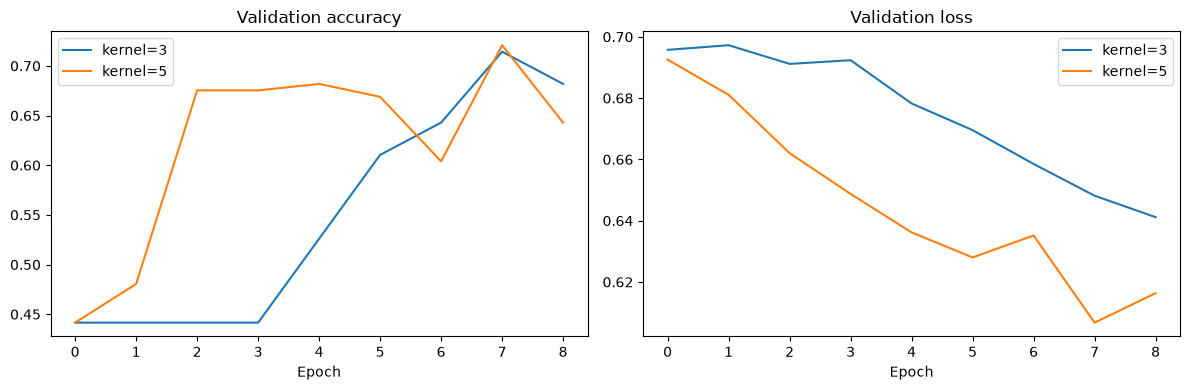

kernel=3: 23649 params, 247.5s total, final train acc 0.710, final val acc 0.682
kernel=5: 65377 params, 462.9s total, final train acc 0.688, final val acc 0.643


In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for k, color in zip((3, 5), ("tab:blue", "tab:orange")):
    h = kernel_results[k]["history"]
    axes[0].plot(h["val_accuracy"], label=f"kernel={k}", color=color)
    axes[1].plot(h["val_loss"], label=f"kernel={k}", color=color)

axes[0].set_title("Validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

for k in (3, 5):
    r = kernel_results[k]
    print(f"kernel={k}: {r['params']} params, {r['seconds']:.1f}s total, "
          f"final train acc {r['history']['accuracy'][-1]:.3f}, "
          f"final val acc {r['history']['val_accuracy'][-1]:.3f}")

**Quantitative results.** After 9 identical epochs:

| | kernel 3x3 | kernel 5x5 |
|---|---|---|
| Parameters | 23,649 | 65,377 |
| Time per epoch | ~27.5s | ~51.4s |
| Final train accuracy | 71.0% | 68.8% |
| Final train loss | 0.639 | 0.580 |
| Final val accuracy | 68.2% | 64.3% |
| Final val loss | 0.641 | 0.616 |
| Best val accuracy | 71.4% (epoch 8) | 72.1% (epoch 8) |

**Qualitative observations.** Both models spend the first 1-2 epochs stuck near chance level (~51-53% train, 44% val) before anything happens. 5x5 breaks away first — already at 62-68% accuracy by epoch 3, while 3x3 doesn't move until epoch 4-5. From there, 5x5's loss stays lower than 3x3's every single epoch, train and validation both, and the gap never closes. Accuracy is messier: both peak at the same epoch (8), within a point of each other, then both drop on epoch 9 — 3x3 drops less, so it actually ends slightly ahead on accuracy despite losing on loss the whole time. With only 5 validation batches (~154 images), a handful of examples crossing the 0.5 boundary is enough to swing accuracy by several points, so I'd trust the loss curve over the final-epoch accuracy here — and loss says 5x5 fits the data better throughout.

**Trade-offs.** 5x5 costs 2.8x the parameters and about 1.9x the time per epoch. What that buys is a head start (learning kicks in 1-2 epochs sooner) and a consistently better loss — which matters more than it looks given how noisy the accuracy comparison is at this scale. Neither model shows anything like the baseline's wild swings (2.3): loss stays in a tight 0.58-0.70 band for both, which is mostly a parameter-count story (23K-65K vs. 17M), not a kernel-size one. Given how close and noisy the accuracy race is after only 9 epochs, I wouldn't call this a clean win for 5x5 — but the loss curve is the more reliable signal, and it points that way.

**One more check — the test set.** Everything above only used train/validation, which is correct while iterating on the architecture, but the dataset ships a separate test split (`ds_test`) we've never actually touched. Using it now, once, for a final read on both models: the baseline (already trained in 2.2) and the CNN — retrained here with the same recipe as the kernel=3 run above, since that's the architecture from section 3 we're keeping.

In [ ]:
ds_test_sup = ds_test.map(to_supervised)

cnn_model.compile(optimizer=Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=["accuracy"])
cnn_model.fit(ds_train_sup, validation_data=ds_val_sup, epochs=9, verbose=2)

baseline_test_loss, baseline_test_acc = keras_baseline_model.evaluate(ds_test_sup, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(ds_test_sup, verbose=0)

print(f"Baseline  -> test loss: {baseline_test_loss:.4f}, test accuracy: {baseline_test_acc:.4f}")
print(f"CNN (k=3) -> test loss: {cnn_test_loss:.4f}, test accuracy: {cnn_test_acc:.4f}")

### 5. Interpretation and Architectural Reasoning

**Why did convolutional layers outperform (or not) the baseline?** On raw final accuracy it's not a clean win — the baseline's best run happened to land at 92.9% after 30 epochs, higher than either CNN variant got in just 9. But that comparison misses the point. The baseline's accuracy depends entirely on which random initialization it gets: the same cell, run three times, gave a model stuck at chance level, a model that peaked near 93% then collapsed to 69%, and a model that peaked near 93% and stayed there. None of those numbers is "the baseline's performance," because the next run could look completely different. Both CNN variants, on the other hand, improved smoothly and monotonically every epoch, with loss staying in a tight 0.58-0.70 band no matter the kernel size or run — nothing close to the baseline's swings between 1 and 140. That's the real win: not a bigger number after a fixed number of epochs, but an optimization problem that converges predictably instead of gambling on initialization. Both variants were still improving at epoch 9 with no sign of plateauing, so more training would likely push either one past the baseline's typical (non-lucky) result — reliably, not by chance.

**What inductive bias does convolution introduce?** The core assumption: a useful local pattern — an edge, a curve, a patch of texture — is worth detecting the same way no matter where it appears. That's weight sharing. Instead of learning a separate weight per pixel like the baseline's flatten+dense layer did, a conv layer learns one small kernel (9 or 25 weights here) and slides it across every position. That single assumption explains the parameter counts we measured — 448 weights for the first conv layer versus 17.28 million for the baseline's first dense layer, covering the same input. A second, related assumption is locality: each kernel only looks at a small neighborhood, encoding the belief that nearby pixels are more related than distant ones — true for natural images, and exactly what the baseline's flatten step throws away by treating a corner pixel and a center pixel as equally unrelated. Stacking these shared, local detectors with pooling in between lets the network build from edges to shapes to bigger structures, and global average pooling at the end adds one more bias specific to whole-image classification: what matters is whether a feature was detected anywhere, not its exact coordinates.

**In what type of problems would convolution not be appropriate?** Convolution's whole advantage comes from assuming there's a meaningful, consistent spatial neighborhood to slide a kernel across — take that away and the bias becomes a liability. Tabular data is the clearest case: a table of customer features (age, income, purchase count) has no "nearby columns are more related than distant ones" — reorder the columns and the data means the same thing, so there's nothing for weight sharing to exploit. A plain dense network or a tree-based model fits that better. Graph data (social networks, molecules) has the same issue: there's no fixed grid to define "the neighboring pixel," which is why those need graph-specific architectures instead. Problems where absolute position is itself the signal are also a bad fit — a fixed-layout form where a field always appears in the same place benefits from position-specific weights, exactly what convolution's translation-invariance throws away. And for long-range dependencies that don't decay with distance — a word's meaning depending on another word many positions away in a long sentence — a small local kernel can't see far enough by itself; that's part of why attention-based architectures, not convolution, are the default for language.

### 6. Deployment in Sagemaker

In this section we will be deploying our model in Amazon Sagemaker, training it and analyze its behavior.

**Disclaimer:** the AWS account provisioned for this course doesn't have permission to create SageMaker endpoints (real-time inference deployment) — attempting to deploy fails at the account/IAM level, not something fixable from the notebook. Because of that, I could only complete the training half of this task, not the actual endpoint deployment.

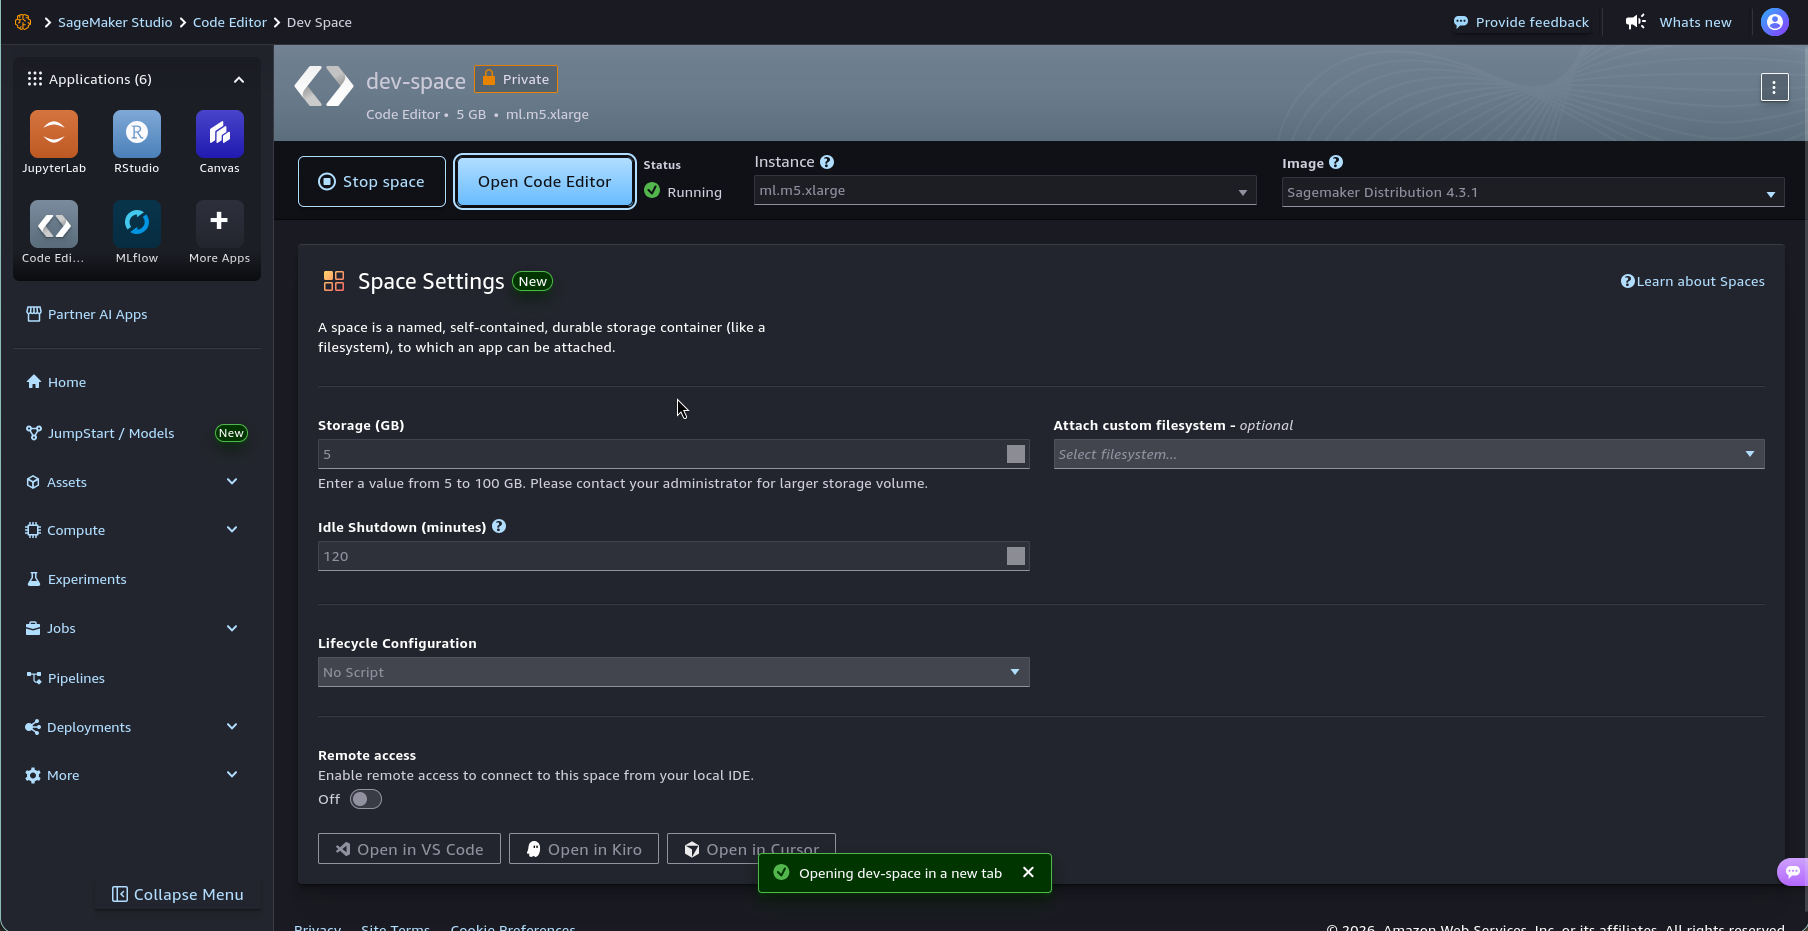

In this time, I felt that SageMaker was too slow, so I decided to scale up the instance and increase the shutdown time.

---

Training the model without convolutional layers

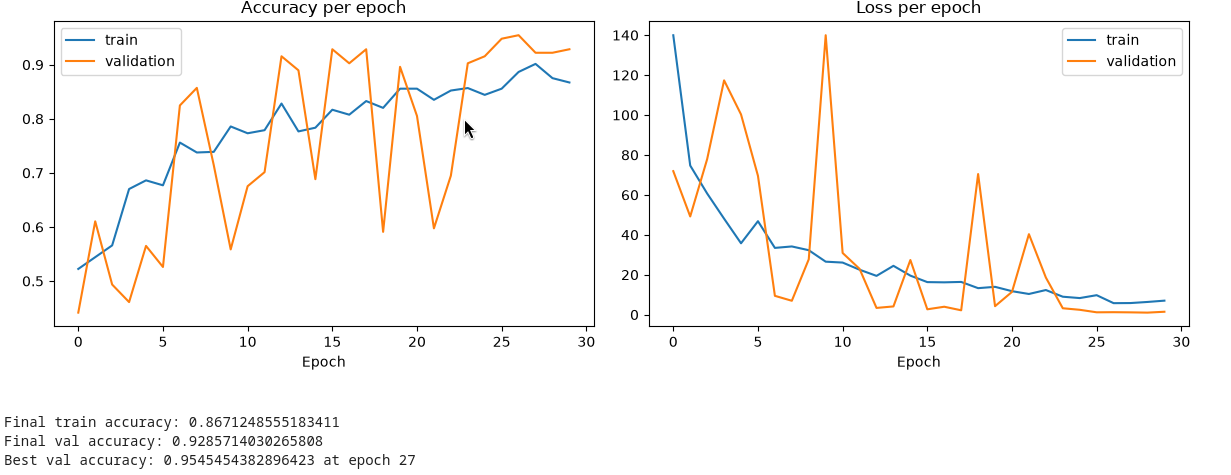

Training the model with convolutional layers and different kernels

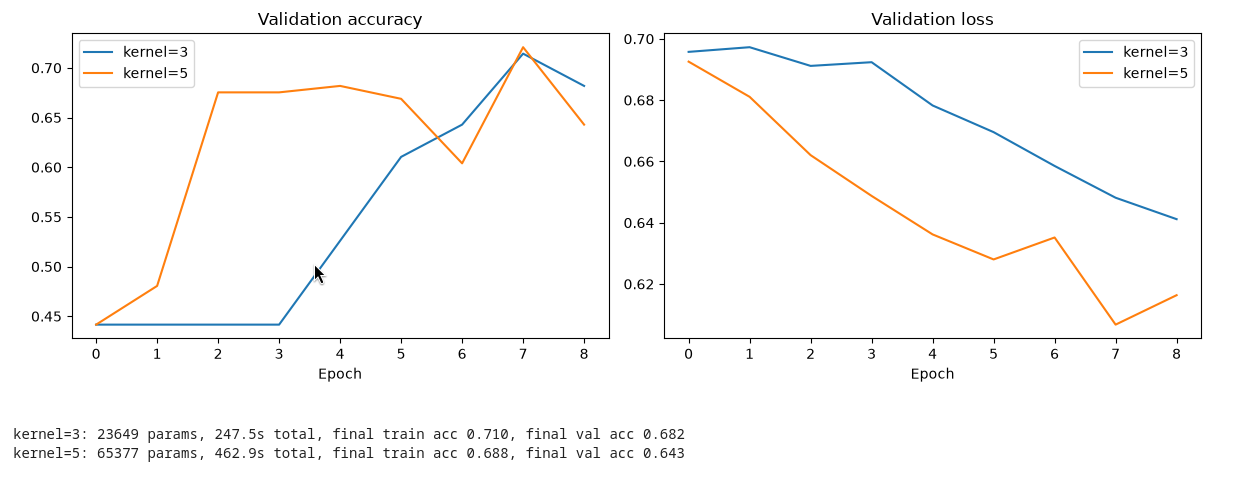



As we can see in the images, we basicly get the same results in Sagemaker than local, the only difference is that Sagemaker takes a lot of time to compile all the notebook and trying to open it. The detecting Kernel option takes me like 1 hour to select it.

### Bonus: visualizing what the CNN learned

Two things worth looking at directly instead of just trusting the numbers: what the first layer's filters actually look like, and what a real image looks like after passing through them.

In [ ]:
first_conv_layer = cnn_model.layers[0]
filters, biases = first_conv_layer.get_weights()
filters_norm = (filters - filters.min()) / (filters.max() - filters.min())

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters_norm[:, :, :, i])
    ax.axis("off")
plt.suptitle("Learned filters — first conv layer (16 filters, 3x3x3)")
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Model

conv_layer_outputs = [layer.output for layer in cnn_model.layers if isinstance(layer, Conv2D)]
activation_model = Model(inputs=cnn_model.inputs, outputs=conv_layer_outputs)

for batch in ds_train.take(1):
    sample_image = batch["image"][0:1]
    break

activations = activation_model.predict(sample_image)
first_layer_activation = activations[0][0]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[:, :, i], cmap="viridis")
    ax.axis("off")
plt.suptitle("Feature maps — first conv layer, one sample image")
plt.tight_layout()
plt.show()